In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/trajectory_analysis/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata_v2.csv',index_col=0)
meta

,sample_id,sample_id2,donor,gw,gender,10xKit,sequencing,dataset
sample,,,,,,,,
9.5gw,gw9,gw9,not_provided_1,9,female,SC3,snRNA-seq,public
11.2gw,gw11,gw11,not_provided_2,11,male,SC3,snRNA-seq,public
14+3gw,gw14,gw14,F20240701,14,male,SC3,snRNA-seq,in-house
15gw,gw15,gw15,not_provided_3,15,female,SC3,scRNA-seq,public
16+4gw,gw16,gw16,F20241018,16,male,SC3,snRNA-seq,in-house
17+2gw,gw17_1,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house
17+3gw,gw17_2,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house
17gw,gw17_3,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public
18+3gw,gw18,gw18,F20220806,18,male,SC3,snRNA-seq,in-house


In [4]:
adata_sub=sc.read('human_coe_sub_for_trajectory_analysis_v4.h5ad')
adata_sub

AnnData object with n_obs × n_vars = 2388 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final', 'cell_type_final_v2', 'scANVI_res2.0', 'cell_type_final_v4'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 

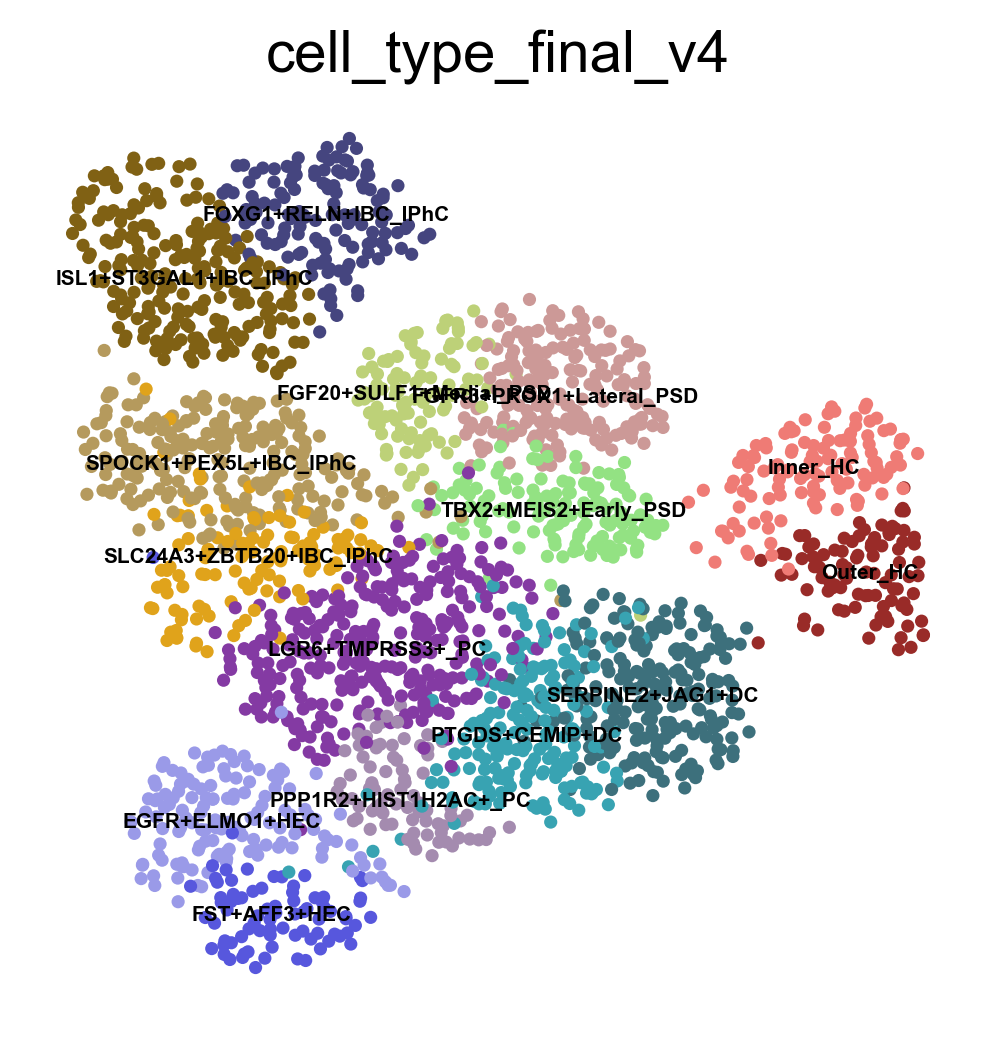

In [5]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_sub,legend_fontsize=5,
    color="cell_type_final_v4",
    palette={"EGFR+ELMO1+HEC": "#9a9ae8", #Circulating cells
             "FST+AFF3+HEC": "#5757dd",
             "FOXG1+RELN+IBC_IPhC": "#45457f",

              "ISL1+ST3GAL1+IBC_IPhC": "#806114",# Surrounding structures
            "SLC24A3+ZBTB20+IBC_IPhC": "#e0a31b",
             "SPOCK1+PEX5L+IBC_IPhC": "#b59a5d",
             "LGR6+TMPRSS3+_PC": "#843aa3",
             "PPP1R2+HIST1H2AC+_PC": "#a48baf",
             "PTGDS+CEMIP+DC": "#38a3b2",
             "SERPINE2+JAG1+DC": "#3d707c",

             "Inner_HC": "#ef7b75",# Lateral wall
             "Outer_HC": "#992b28",
             "FGFR3+PROX1+Lateral_PSD": "#cc9997",
             "FGF20+SULF1+Medial_PSD": "#bdd178",
             "TBX2+MEIS2+Early_PSD": "#93e283",
             
            
            },

    size=40,
legend_loc='on data',

    
)

In [6]:
cluster_annotation = {
 'FGF20+SULF1+Medial_PSD': 'FGFR3+PROX1+Lateral_PSD',
     'TBX2+MEIS2+Early_PSD': 'TBX2+MEIS2+Early_PSD',
     'FGFR3+PROX1+Lateral_PSD': 'FGF20+SULF1+Medial_PSD',
    
     'Outer_HC': 'Outer_HC',
     'Inner_HC': 'Inner_HC',
    
     'LGR6+TMPRSS3+_PC': 'LGR6+TMPRSS3+_PC',
    
    'LGR6+TMPRSS3+_PC': 'LGR6+TMPRSS3+_PC',
   
    'PPP1R2+HIST1H2AC+_PC': 'PPP1R2+HIST1H2AC+_PC',
    
     'ISL1+ST3GAL1+IBC_IPhC': 'ISL1+ST3GAL1+IBC_IPhC',
    'FOXG1+RELN+IBC_IPhC': 'FOXG1+RELN+IBC_IPhC',
     'SPOCK1+PEX5L+IBC_IPhC': 'SPOCK1+PEX5L+IBC_IPhC',
    'SLC24A3+ZBTB20+IBC_IPhC': 'SLC24A3+ZBTB20+IBC_IPhC',
    
     'SERPINE2+JAG1+DC': 'SERPINE2+JAG1+DC',
    'PTGDS+CEMIP+DC': 'PTGDS+CEMIP+DC',
    
     'EGFR+ELMO1+HEC': 'EGFR+ELMO1+HEC',
    'FST+AFF3+HEC': 'FST+AFF3+HEC',

}
adata_sub.obs['cell_type_final_v4'] = adata_sub.obs['cell_type_final_v4'].map(cluster_annotation).astype('category')

In [7]:
cluster_annotation = {
    'FGFR3+PROX1+Lateral_PSD': 'CoE_prosensory',
    'FGF20+SULF1+Medial_PSD':'CoE_prosensory',
 
     'TBX2+MEIS2+Early_PSD': 'CoE_prosensory',
     
    
     'Outer_HC': 'Cochlear_HCs',
     'Inner_HC': 'Cochlear_HCs',
    
     'LGR6+TMPRSS3+_PC': 'Pillar_cells',
    
    'LGR6+TMPRSS3+_PC': 'Pillar_cells',
   
    'PPP1R2+HIST1H2AC+_PC': 'Pillar_cells',
    
     'ISL1+ST3GAL1+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'FOXG1+RELN+IBC_IPhC': 'Inner_border-phalangeal_cells',
     'SPOCK1+PEX5L+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'SLC24A3+ZBTB20+IBC_IPhC': 'Inner_border-phalangeal_cells',
    
     'SERPINE2+JAG1+DC': 'Deiters_cells',
    'PTGDS+CEMIP+DC': 'Deiters_cells',
    
     'EGFR+ELMO1+HEC': 'Hensen_cells',
    'FST+AFF3+HEC': 'Hensen_cells',

}
adata_sub.obs['cell_type_final_v3'] = adata_sub.obs['cell_type_final_v4'].map(cluster_annotation).astype('category')

In [10]:
cluster_annotation = {
    'FGFR3+PROX1+Lateral_PSD': 'Lateral_PSD',
    'FGF20+SULF1+Medial_PSD':'Medial_PSD',
 
     'TBX2+MEIS2+Early_PSD': 'Early_PSD',
     
    
     'Outer_HC': 'Cochlear_HCs',
     'Inner_HC': 'Cochlear_HCs',
    
     'LGR6+TMPRSS3+_PC': 'Pillar_cells',
    
    'LGR6+TMPRSS3+_PC': 'Pillar_cells',
   
    'PPP1R2+HIST1H2AC+_PC': 'Pillar_cells',
    
     'ISL1+ST3GAL1+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'FOXG1+RELN+IBC_IPhC': 'Inner_border-phalangeal_cells',
     'SPOCK1+PEX5L+IBC_IPhC': 'Inner_border-phalangeal_cells',
    'SLC24A3+ZBTB20+IBC_IPhC': 'Inner_border-phalangeal_cells',
    
     'SERPINE2+JAG1+DC': 'Deiters_cells',
    'PTGDS+CEMIP+DC': 'Deiters_cells',
    
     'EGFR+ELMO1+HEC': 'Hensen_cells',
    'FST+AFF3+HEC': 'Hensen_cells',

}
adata_sub.obs['cell_type_final_v5'] = adata_sub.obs['cell_type_final_v4'].map(cluster_annotation).astype('category')

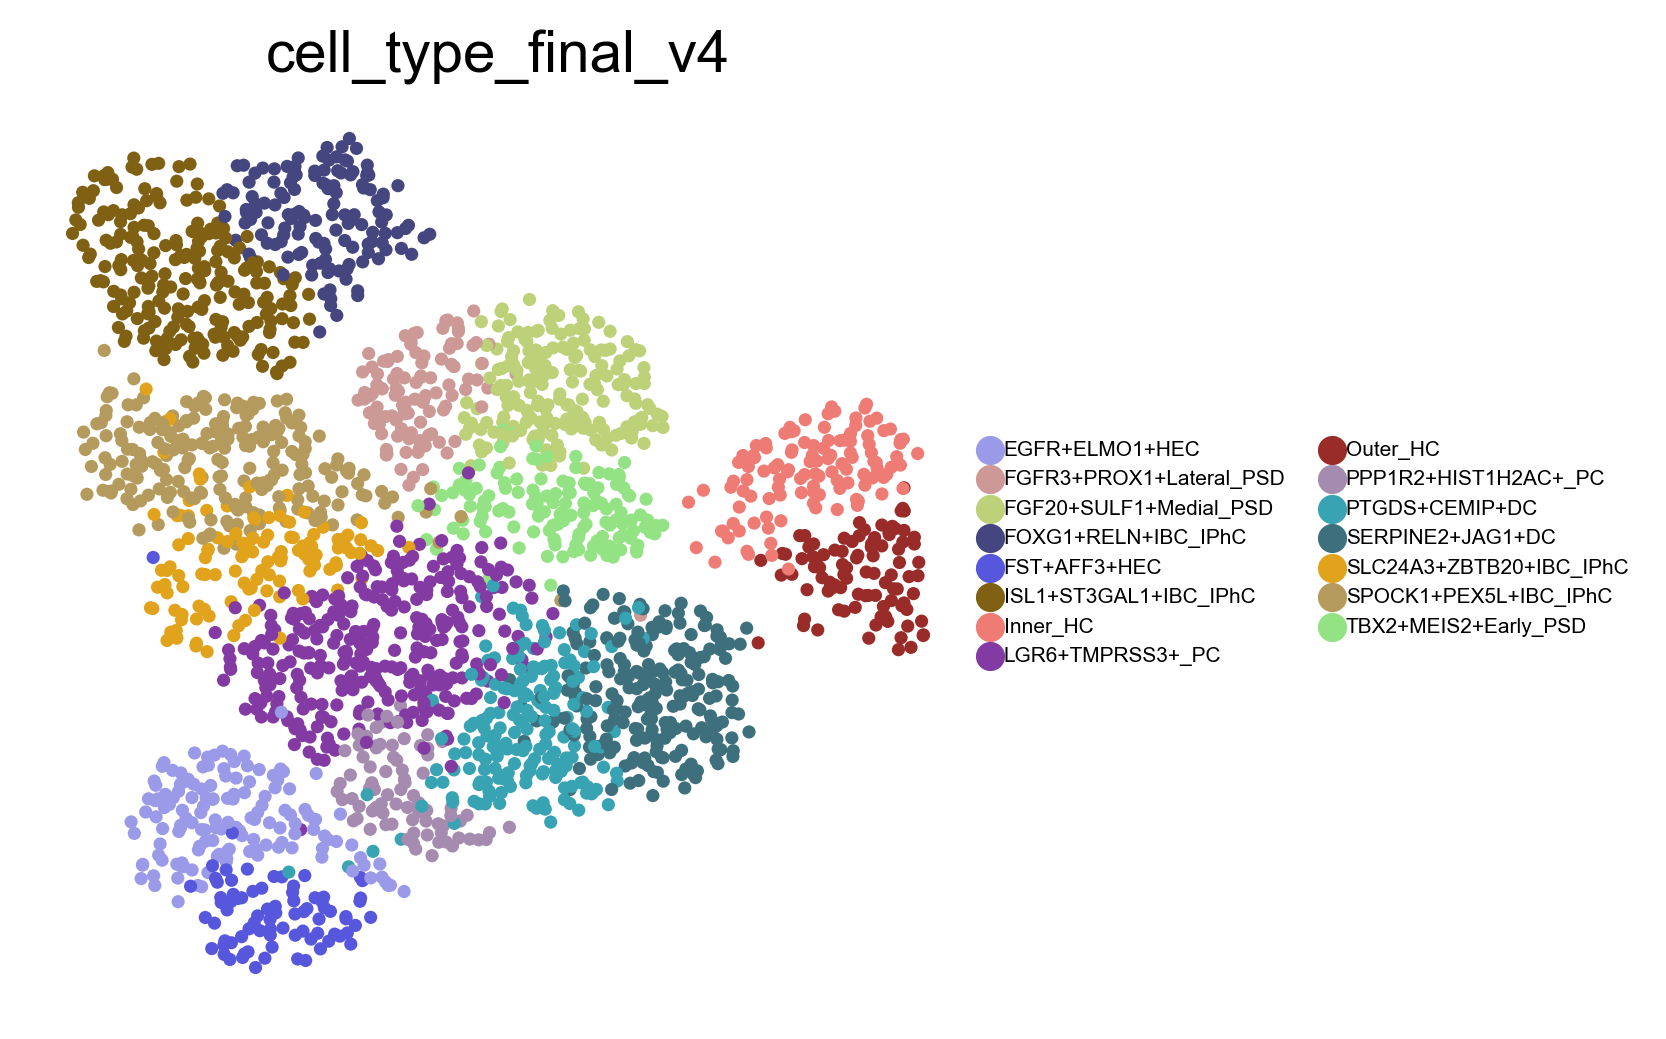

In [8]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_sub,legend_fontsize=5,
    color="cell_type_final_v4",
    palette={"EGFR+ELMO1+HEC": "#9a9ae8", #Circulating cells
             "FST+AFF3+HEC": "#5757dd",
             "FOXG1+RELN+IBC_IPhC": "#45457f",

              "ISL1+ST3GAL1+IBC_IPhC": "#806114",# Surrounding structures
            "SLC24A3+ZBTB20+IBC_IPhC": "#e0a31b",
             "SPOCK1+PEX5L+IBC_IPhC": "#b59a5d",
             "LGR6+TMPRSS3+_PC": "#843aa3",
             "PPP1R2+HIST1H2AC+_PC": "#a48baf",
             "PTGDS+CEMIP+DC": "#38a3b2",
             "SERPINE2+JAG1+DC": "#3d707c",

             "Inner_HC": "#ef7b75",# Lateral wall
             "Outer_HC": "#992b28",
             "FGFR3+PROX1+Lateral_PSD": "#cc9997",
             "FGF20+SULF1+Medial_PSD": "#bdd178",
             "TBX2+MEIS2+Early_PSD": "#93e283",
             
            
            },


    size=40,


    
)#legend_loc='on data',

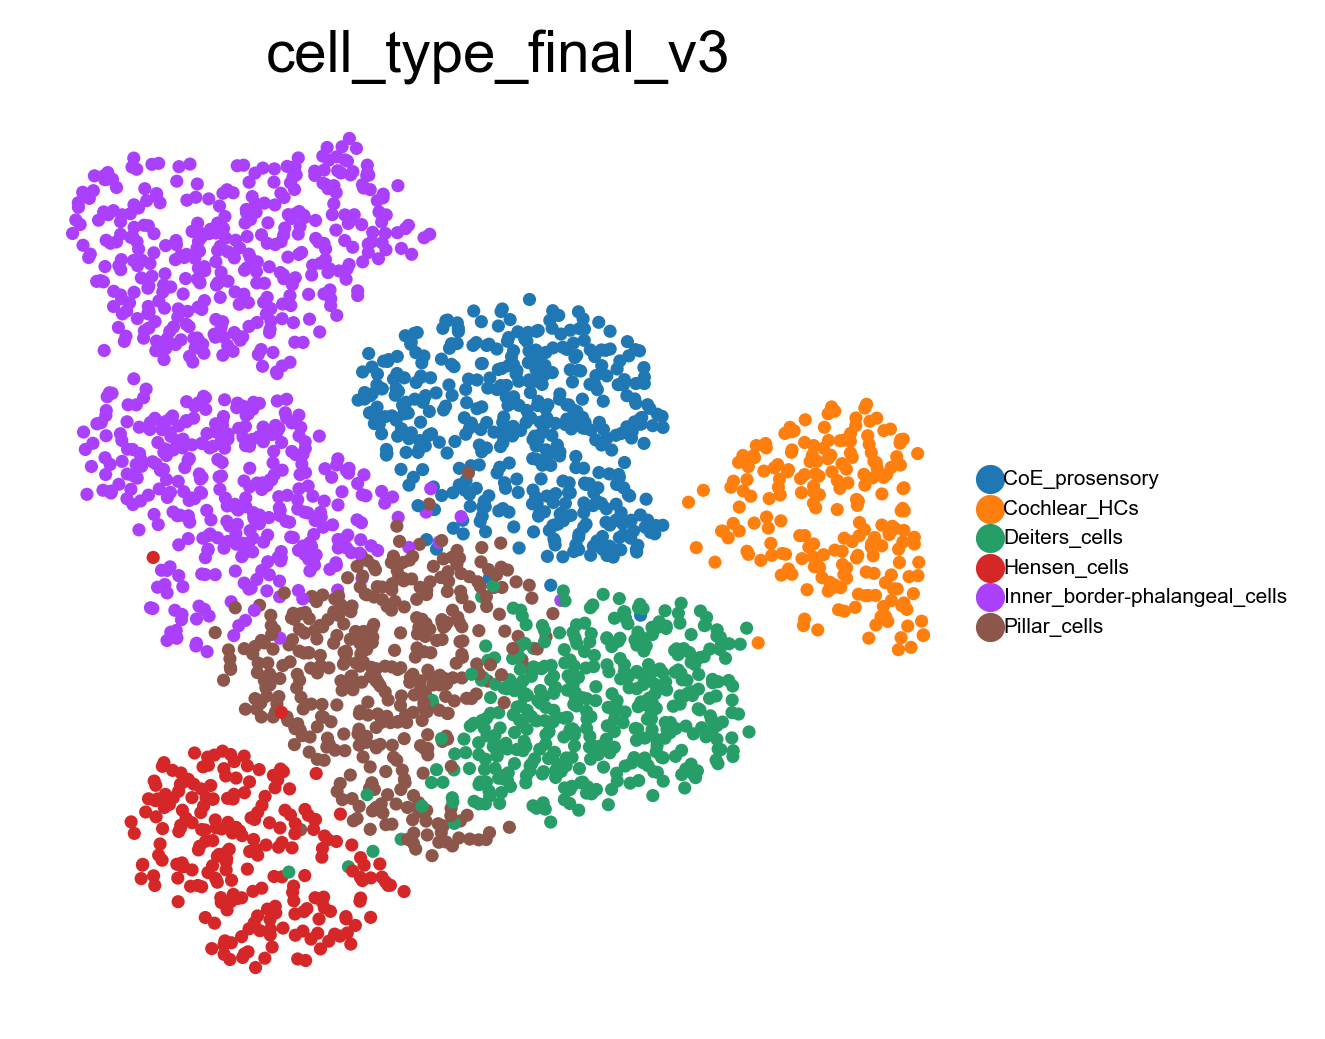

In [9]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_sub,legend_fontsize=5,
    color="cell_type_final_v3",
    


    size=40,


    
)#legend_loc='on data',

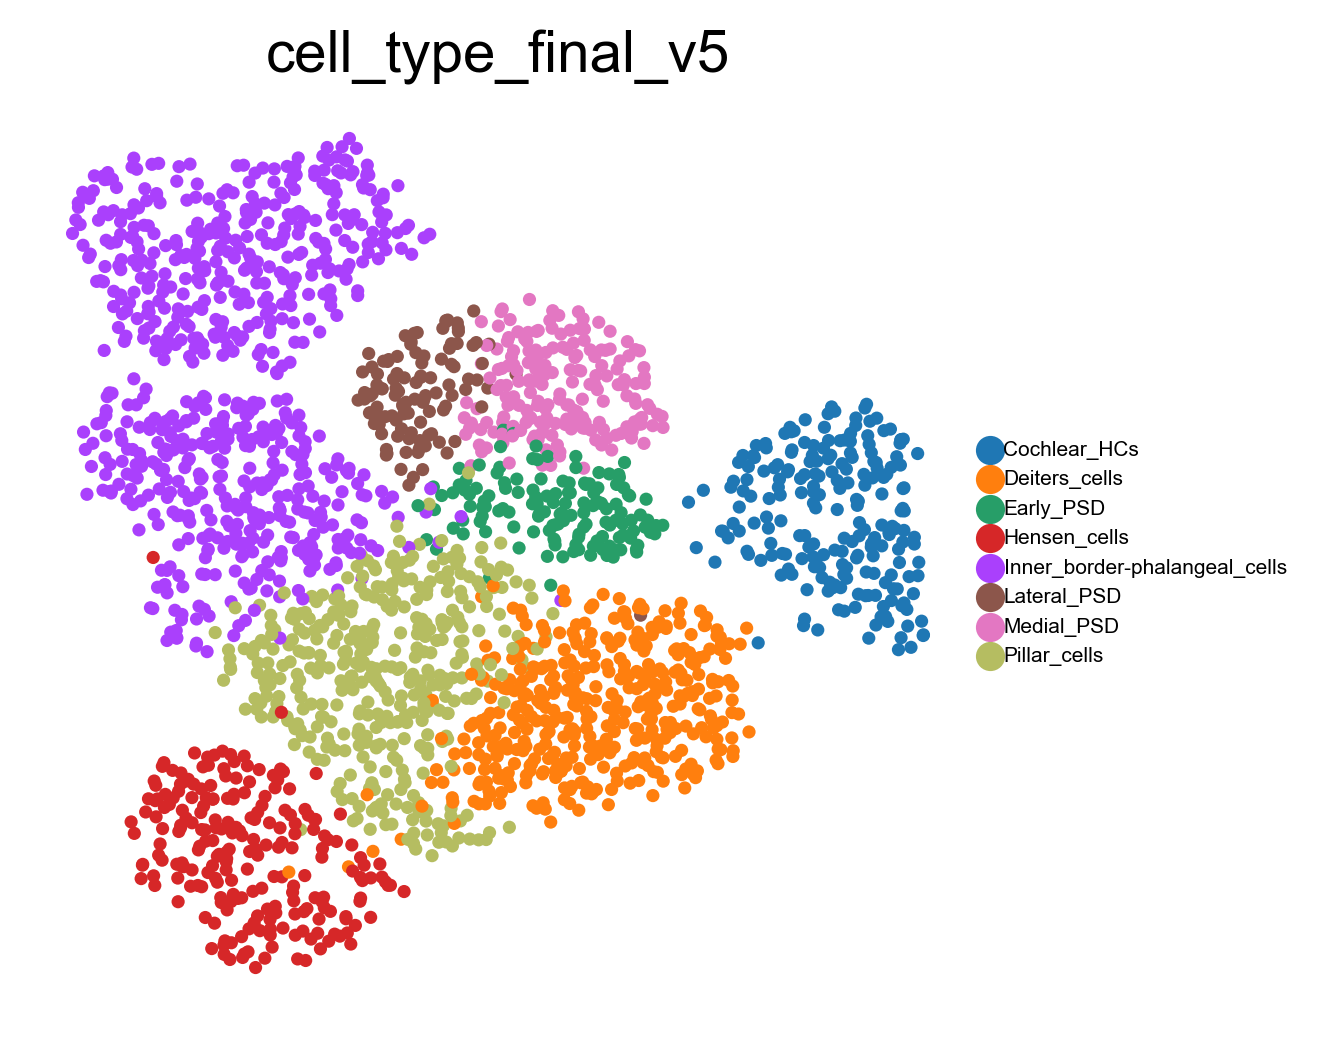

In [11]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata_sub,legend_fontsize=5,
    color="cell_type_final_v5",
    


    size=40,


    
)#legend_loc='on data',

In [12]:
holder = []
for sample in meta.index:
    print(sample)
    # Load 10x data as AnnData
    #adata_sample = sc.read_10x_mtx(data_dir+'rawdata_pbx3_neo/'+sample+'/outs/filtered_feature_bc_matrix/',cache=True)
    holder.append(sc.read(data_dir+sample+'/human_gw_raw.h5ad',cache=True)) 
    # Set names of observation as sample + _ + barcode/probe
    holder[-1].obs_names = [sample+'_'+i.split('-')[0] for i in holder[-1].obs_names]
    # Filer genes expressed in less than 3 cells
    sc.pp.filter_genes(holder[-1], min_cells=3)
    # Filer cells with less than 10 genes expressed
    sc.pp.filter_cells(holder[-1], min_genes=10)
    # add in metadata
    holder[-1].obs['sample'] = sample
    for val in meta.columns:
        holder[-1].obs[val] = meta[val][sample]
    # Extract mitochondial genes
    mito_genes = [name for name in holder[-1].var_names if name.startswith('MT-')]
    #for each cell compute fraction of counts in mito genes vs. all genes
    #the `.A1` is only necessary, as X is sparse - it transform to a dense array after summing
    holder[-1].obs['percent_mito'] = np.sum(
        holder[-1][:, mito_genes].X, axis=1).A1 / np.sum(holder[-1].X, axis=1).A1
    #add the total counts per cell as observations-annotation to adata
    holder[-1].obs['n_counts'] = holder[-1].X.sum(axis=1).A1
    print('Total number of cells: {:d}'.format(holder[-1].n_obs))
    print('Total number of genes: {:d}'.format(holder[-1].n_vars))

9.5gw
Total number of cells: 4284
Total number of genes: 22512
11.2gw
Total number of cells: 4051
Total number of genes: 26703
14+3gw
Total number of cells: 12081
Total number of genes: 29961
15gw
Total number of cells: 2146
Total number of genes: 18995
16+4gw
Total number of cells: 8708
Total number of genes: 29950
17+2gw
Total number of cells: 6773
Total number of genes: 26118
17+3gw
Total number of cells: 7148
Total number of genes: 26633
17gw
Total number of cells: 4538
Total number of genes: 19729
18+3gw
Total number of cells: 9595
Total number of genes: 26884
20gw
Total number of cells: 3833
Total number of genes: 26808
22+2gw_1
Total number of cells: 5837
Total number of genes: 28742
22+2gw_2
Total number of cells: 7861
Total number of genes: 26226
23+2gw
Total number of cells: 3597
Total number of genes: 24258
25+6gw
Total number of cells: 13936
Total number of genes: 28576
26+3gw
Total number of cells: 7872
Total number of genes: 25874


In [13]:
# confirm N samples
print(len(holder))
# merge datasets
adata_all = holder[0].concatenate(holder[1:],join='outer',index_unique=None)
# copy of this matrix in Compressed Sparse Row format
adata_all.X = adata_all.X.tocsr()
adata_all

15


C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\3203741929.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = holder[0].concatenate(holder[1:],join='outer',index_unique=None)


AnnData object with n_obs × n_vars = 102260 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'sample_id2', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'Gene-10', 'n_cells_by_counts-10', 'mean_counts-10', 'pct_dropout_by_counts-10', 'total_counts-10', 'highly_variable-10', 'means-10', 'dispersions-10', 'dispersions_norm-10', 'n_ce

In [14]:
adata_new=adata_all[adata_sub.obs.index]
adata_new

View of AnnData object with n_obs × n_vars = 2388 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'sample_id2', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'Gene-10', 'n_cells_by_counts-10', 'mean_counts-10', 'pct_dropout_by_counts-10', 'total_counts-10', 'highly_variable-10', 'means-10', 'dispersions-10', 'dispersions_norm-10',

In [20]:
#adata_new.layers['counts']=adata_integration.layers['counts']
adata_new.obsp['connectivities']=adata_sub.obsp['connectivities']
adata_new.obsp['distances']=adata_sub.obsp['distances']

adata_new.obsm['X_pca']=adata_sub.obsm['X_pca']
adata_new.obsm['X_scANVI']=adata_sub.obsm['X_scANVI']
adata_new.obsm['X_scVI']=adata_sub.obsm['X_scVI']
adata_new.obsm['X_umap']=adata_sub.obsm['X_umap']
adata_new.obsm['_scvi_extra_categorical_covs']=adata_sub.obsm['_scvi_extra_categorical_covs']
adata_new.obsm['_scvi_extra_continuous_covs']=adata_sub.obsm['_scvi_extra_continuous_covs']

adata_new.uns['_scvi_manager_uuid']=adata_sub.uns['_scvi_manager_uuid']
adata_new.uns['_scvi_uuid']=adata_sub.uns['_scvi_uuid']
adata_new.uns['annotation_colors']=adata_sub.uns['annotation_colors']
adata_new.uns['ccgs']=adata_sub.uns['ccgs']
adata_new.uns['cell_type_final_colors']=adata_sub.uns['cell_type_final_colors']
adata_new.uns['cell_type_final_v2_colors']=adata_sub.uns['cell_type_final_v2_colors']
adata_new.uns['hvg']=adata_sub.uns['hvg']
adata_new.uns['rank_genes_groups']=adata_sub.uns['rank_genes_groups']
adata_new.uns['log1p']=adata_sub.uns['log1p']
adata_new.uns['neighbors']=adata_sub.uns['neighbors']
adata_new.uns['sample_colors']=adata_sub.uns['sample_colors']
adata_new.uns['umap']=adata_sub.uns['umap']



adata_new.obs['cell_type_final']=adata_sub.obs['cell_type_final']
adata_new.obs['cell_type_final_v2']=adata_sub.obs['cell_type_final_v2']
adata_new.obs['cell_type_final_v3']=adata_sub.obs['cell_type_final_v3']
adata_new.obs['cell_type_final_v4']=adata_sub.obs['cell_type_final_v4']
adata_new.obs['cell_type_final_v5']=adata_sub.obs['cell_type_final_v5']
adata_new.obs['low_ncounts']=adata_sub.obs['low_ncounts']
adata_new.obs['low_ncounts_high_mito']=adata_sub.obs['low_ncounts_high_mito']
adata_new.obs['S_score']=adata_sub.obs['S_score']
adata_new.obs['G2M_score']=adata_sub.obs['G2M_score']
adata_new.obs['phase']=adata_sub.obs['phase']
adata_new.obs['scrublet_score']=adata_sub.obs['scrublet_score']
adata_new.obs['scrublet_cluster_score']=adata_sub.obs['scrublet_cluster_score']
adata_new.obs['zscore']=adata_sub.obs['zscore']
adata_new.obs['bh_pval']=adata_sub.obs['bh_pval']
adata_new.obs['bonf_pval']=adata_sub.obs['bonf_pval']
adata_new.obs['is_doublet']=adata_sub.obs['is_doublet']
adata_new.obs['is_doublet_scrub']=adata_sub.obs['is_doublet_scrub']
adata_new.obs['_scvi_batch']=adata_sub.obs['_scvi_batch']
adata_new.obs['_scvi_labels']=adata_sub.obs['_scvi_labels']

In [21]:
adata_new.layers["counts"] = adata_new.X.copy() # preserve counts

In [22]:
adata_new.obsm['X_umap']=adata_sub.obsm['X_umap']
#adata_new.obs['cell_type_final_v4']=adata_sub.obs['cell_type_final_v4']

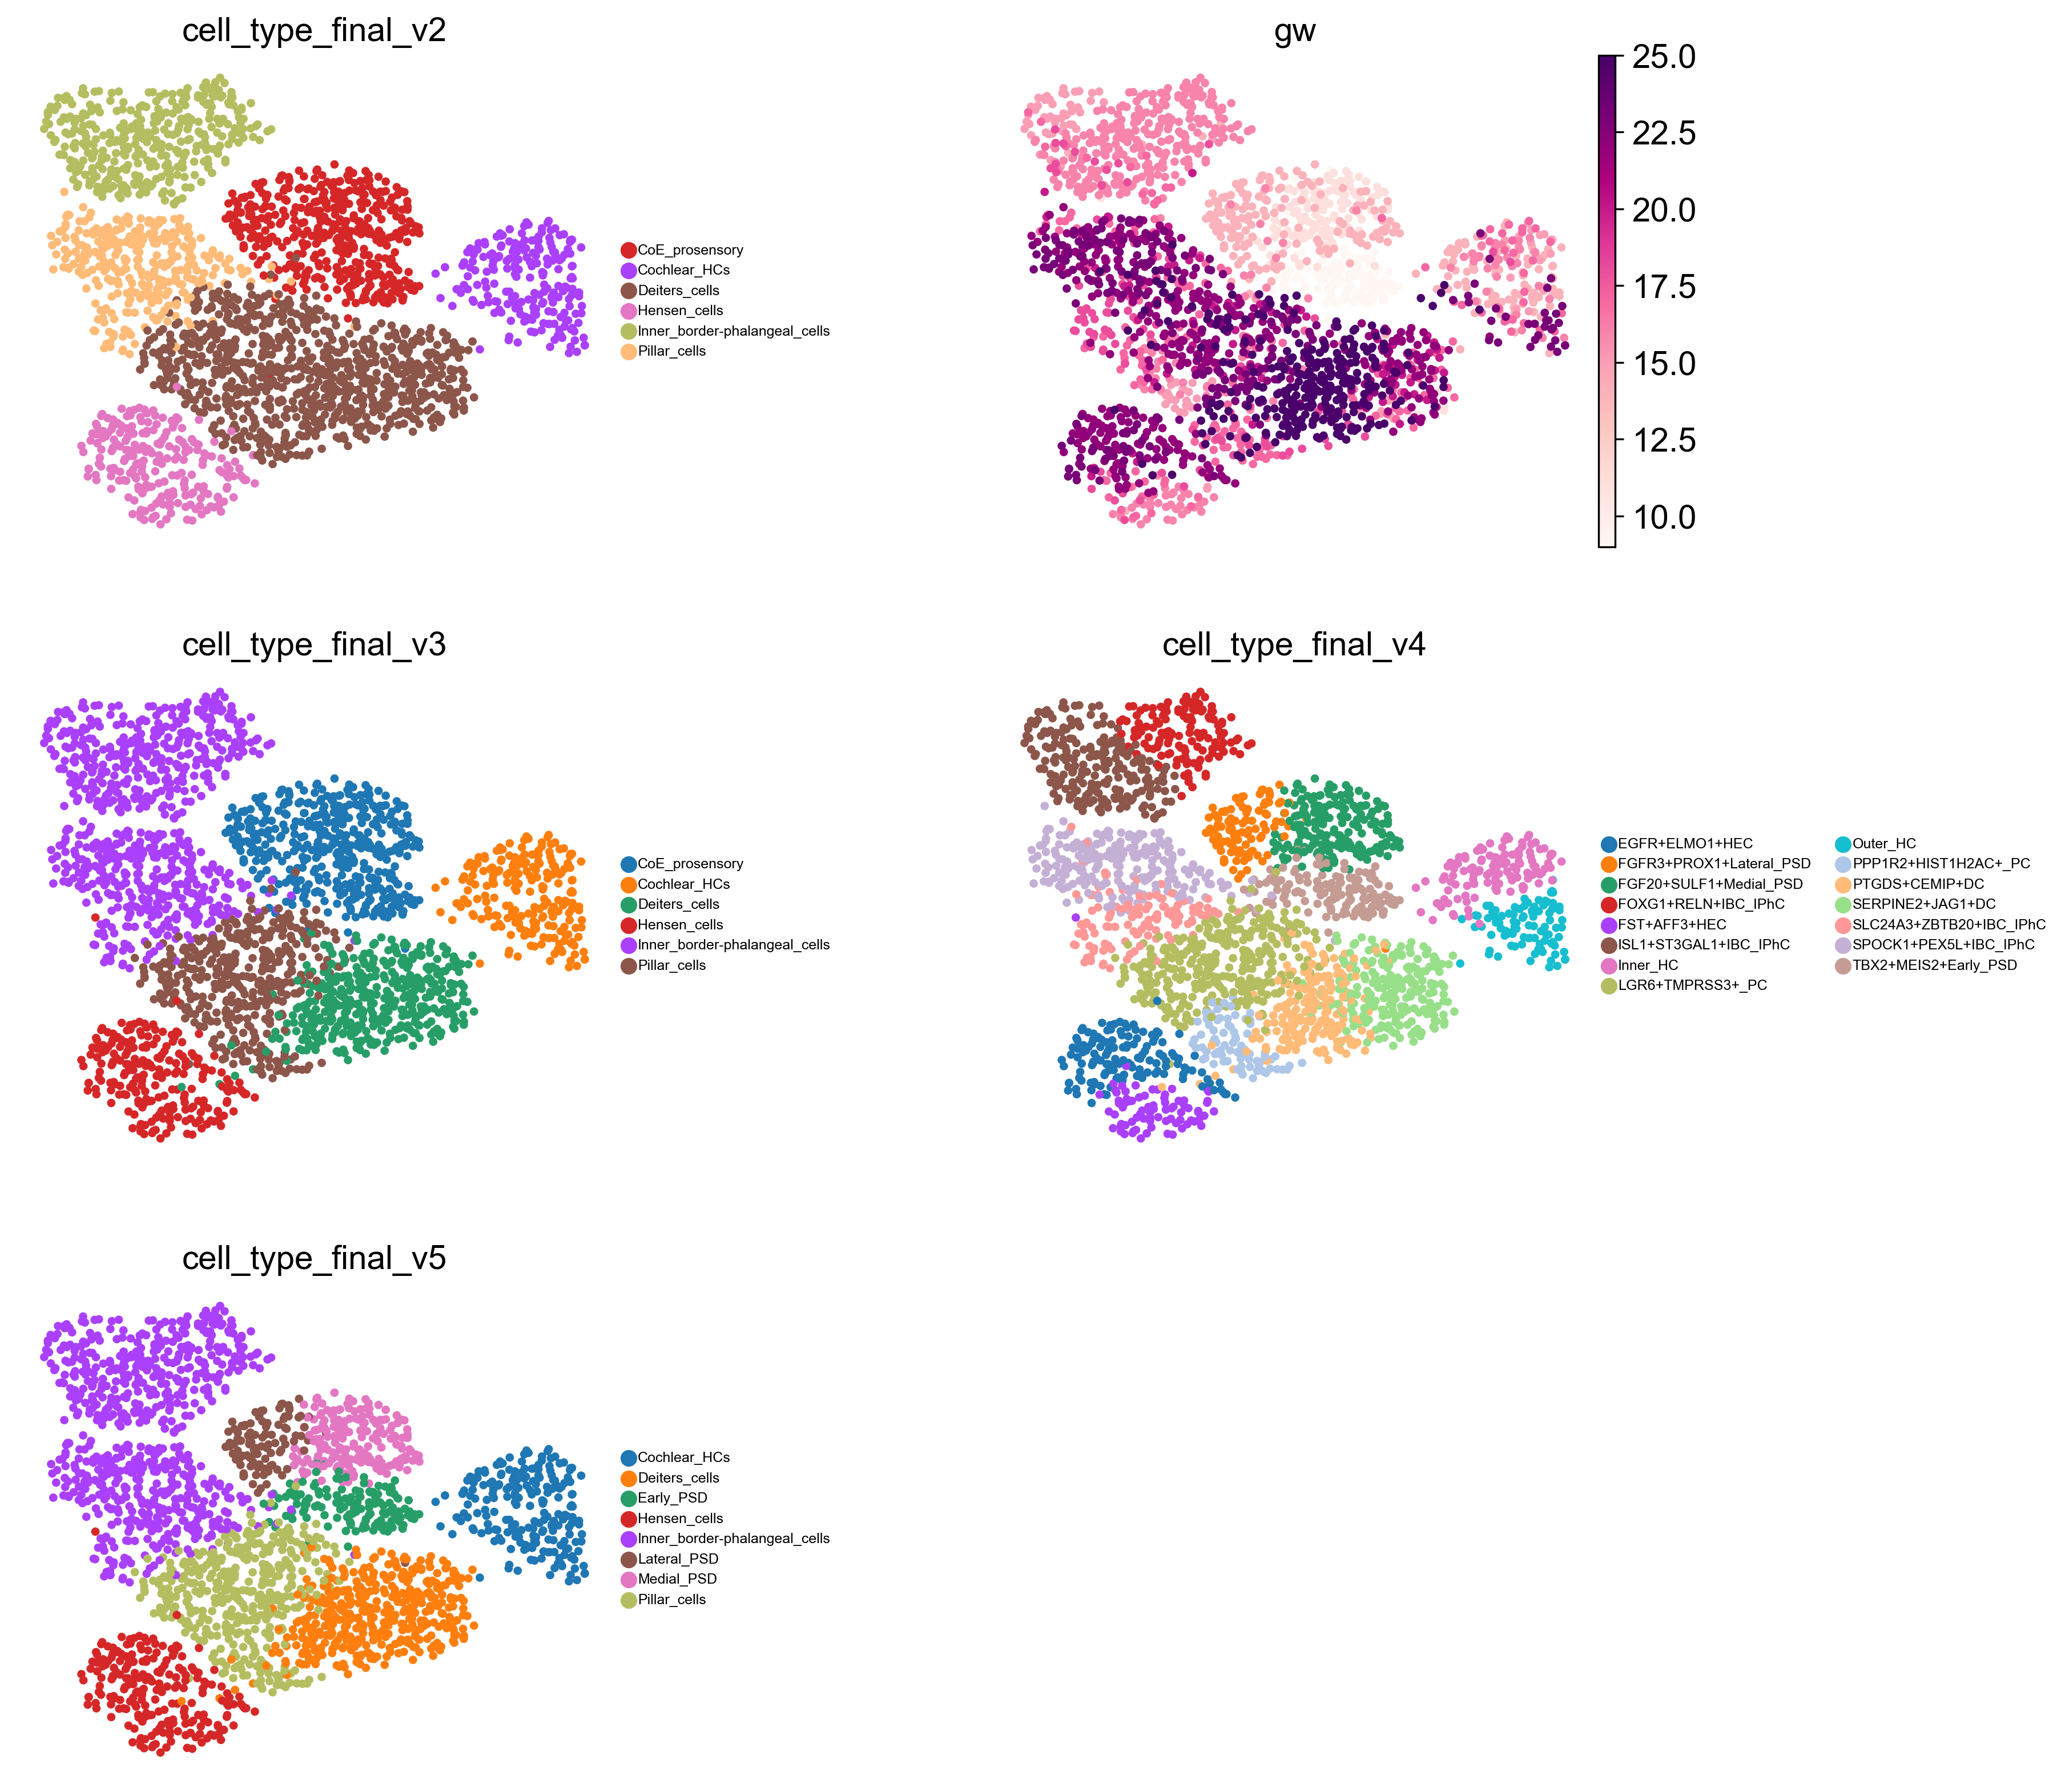

In [23]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_new, color=['cell_type_final_v2','gw', 
                                'cell_type_final_v3','cell_type_final_v4',
                               'cell_type_final_v5',
                            ],
           size=50,
           legend_fontsize=6,ncols = 2,wspace = 0.5,
           color_map = 'RdPu', 
          )

In [24]:
small_marker_dict={
    
      'Epithelium':["EPCAM",],
 'supporting cells':["OTOG","OTOGL","USH1C",],
    'Lateral PSD':[ "FGFR3","PROX1",],
    'Medial PSD':[ "TBX2","FGF20",],
     'Pillar cells':[ "LGR6","CD44",'P75','NPY',],
    'Deiters cells':[ "LGR5",'JAG1','CEACAM16','SERPINE2'],
    'Inner Border/ Inner phalangeal cells':[ "EPYC",'AQP4'],
    'Hensen cells':[ "FST",'AFF3'],

}
# check if the markers are in the data
smarker_genes_in_data = dict()
for ct, markers in small_marker_dict.items():
    markers_found = list()
    for marker in markers:
        if marker in adata_new.var.index:
            markers_found.append(marker)
    smarker_genes_in_data[ct] = markers_found
#del [] # remove the last marker
del_markers = list()
for ct, markers in smarker_genes_in_data.items():
    if markers==[]:
        del_markers.append(ct)
for ct in del_markers:
    del smarker_genes_in_data[ct]

In [25]:
adata_new.obs['cell_type2']=adata_new.obs['cell_type_final_v3'].cat.reorder_categories(['Cochlear_HCs','CoE_prosensory','Pillar_cells','Deiters_cells',
                                                                               'Inner_border-phalangeal_cells','Hensen_cells',
    
])


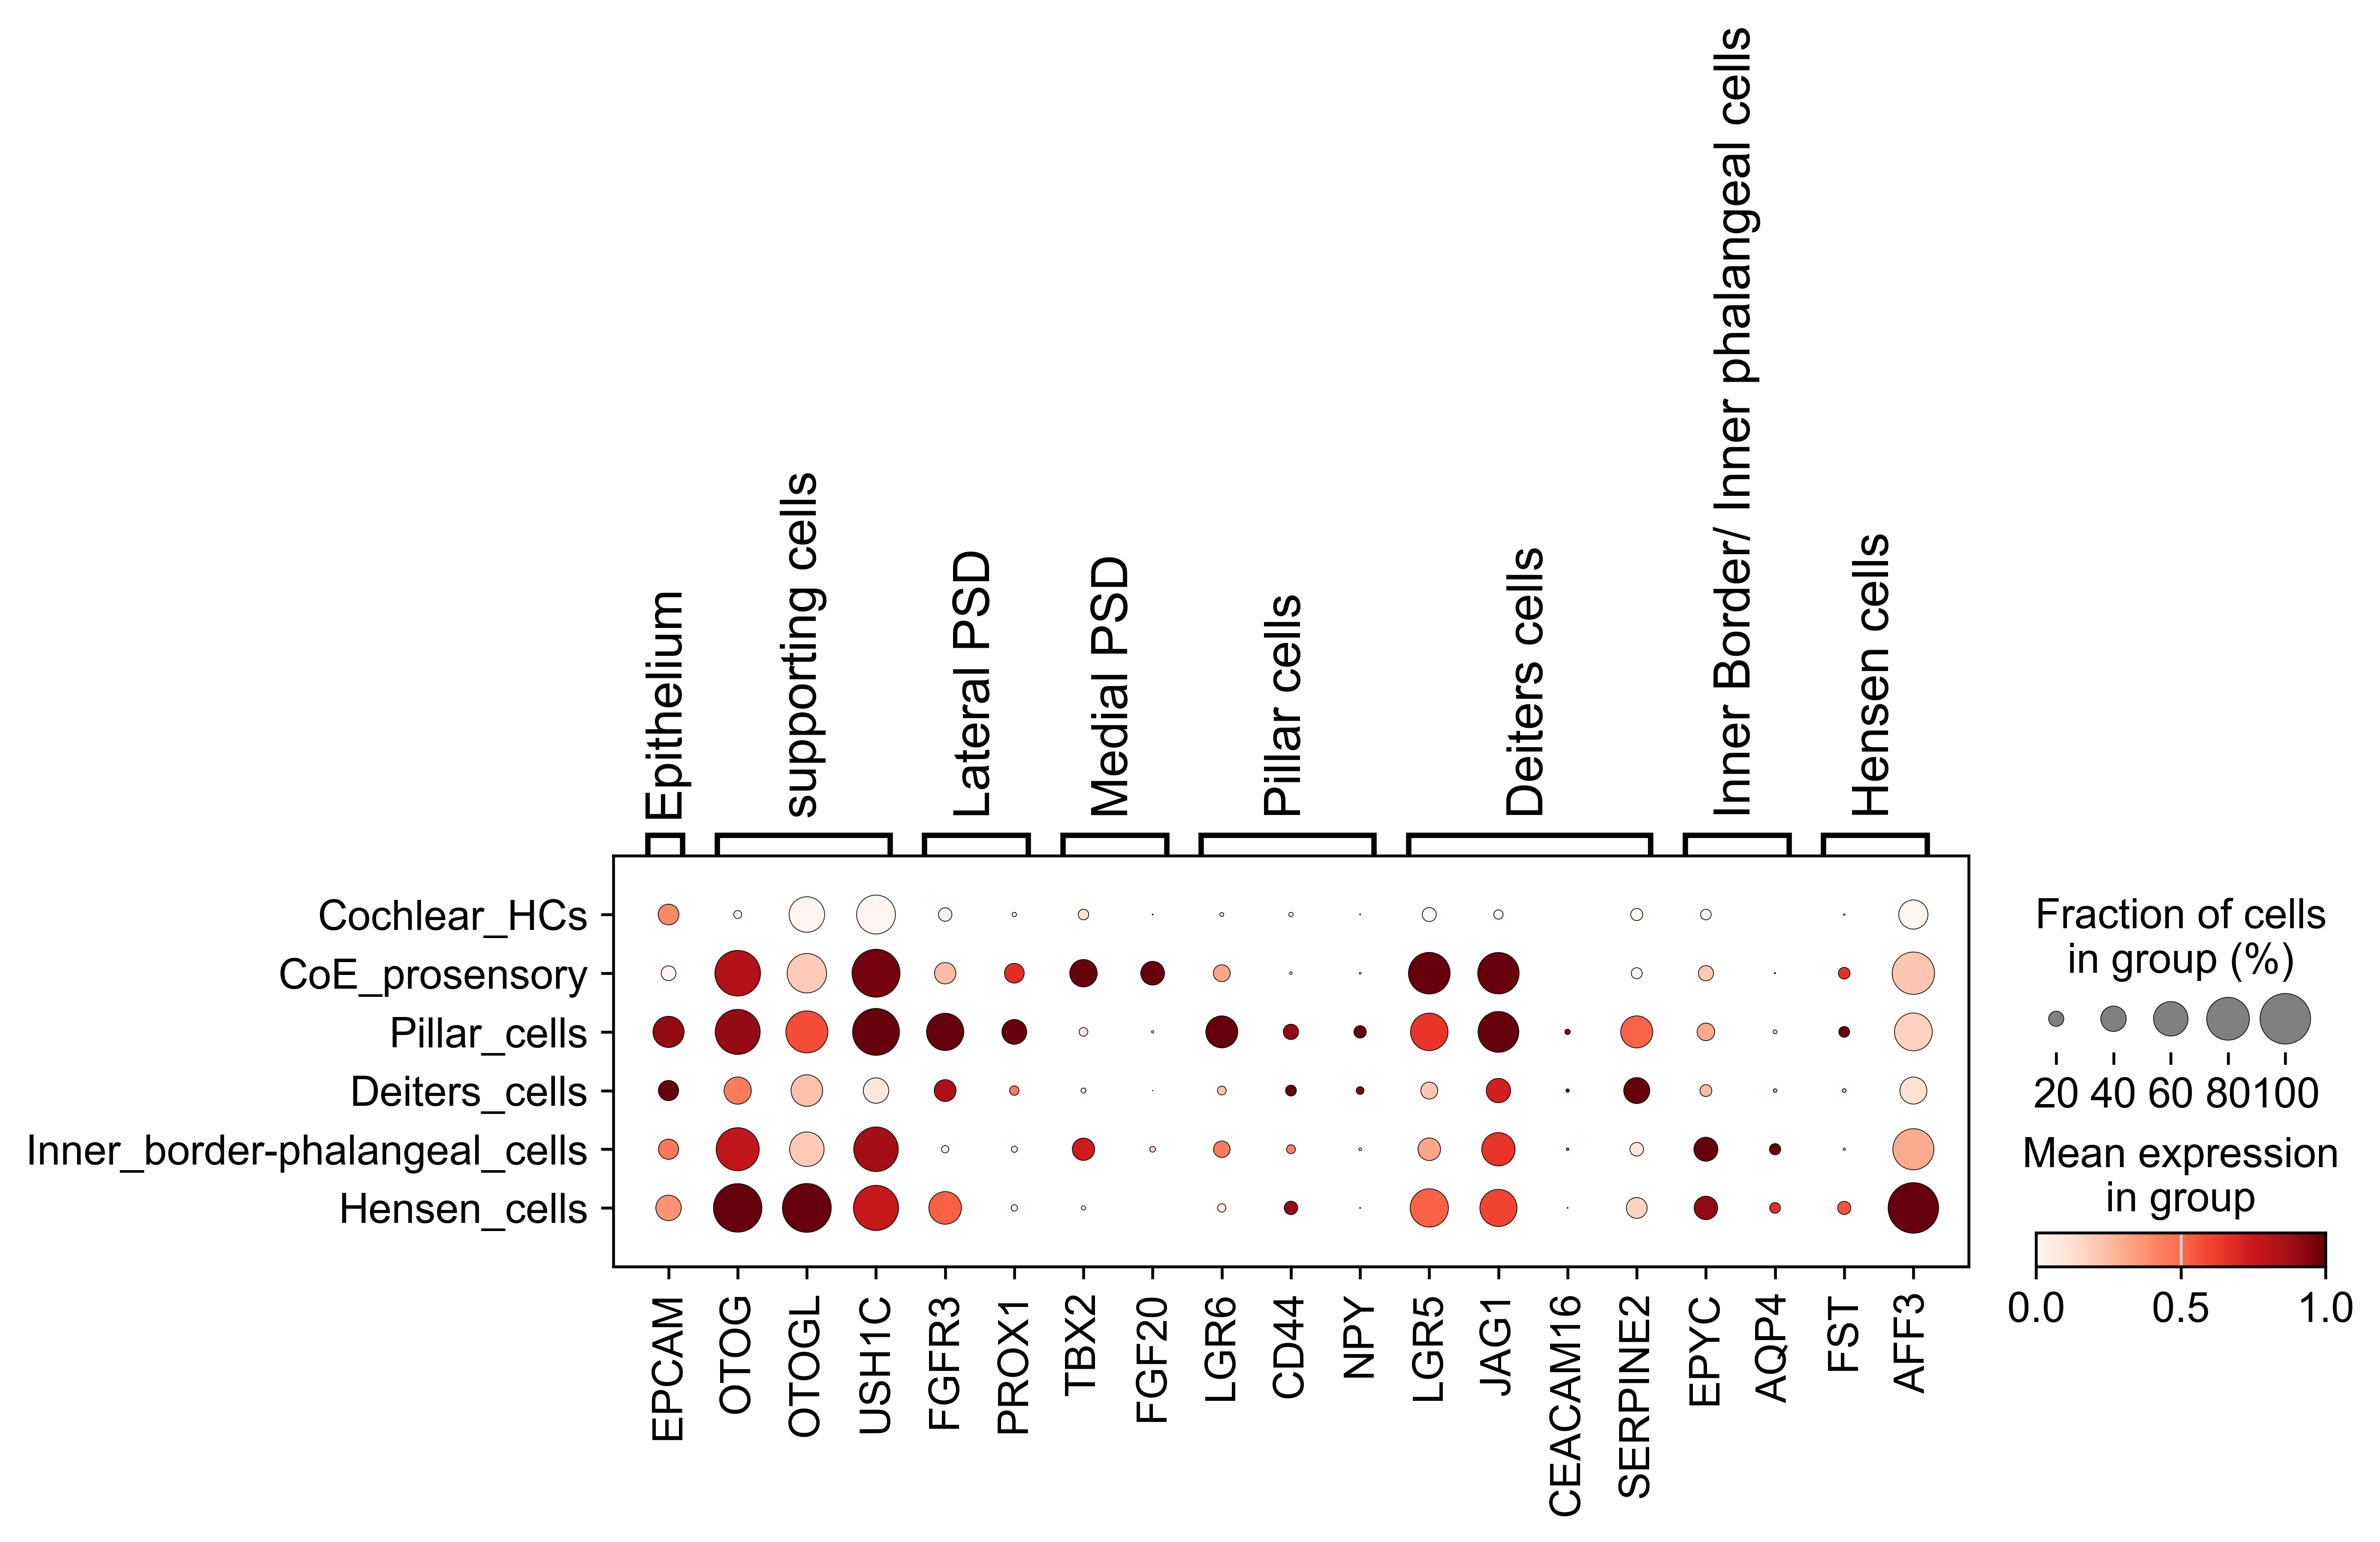

In [26]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=300,dpi_save=600)
#sc.tl.dendrogram(adata, groupby='cell_type_final')
sc.pl.dotplot(
    adata_new,
    groupby="cell_type2",
    var_names=smarker_genes_in_data,
  #dendrogram=True,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
     save="human_fetal_cochlea_epithlium_refined.pdf"
)

In [68]:
small_marker_dict={
    
     
    
    'Early_PSD':[ "SOX2",],
    'Lateral PSD':[ "FGFR3","PROX1",],
    'Medial PSD':[ "TBX2","FGF20",],

}
# check if the markers are in the data
smarker_genes_in_data = dict()
for ct, markers in small_marker_dict.items():
    markers_found = list()
    for marker in markers:
        if marker in adata_new.var.index:
            markers_found.append(marker)
    smarker_genes_in_data[ct] = markers_found
#del [] # remove the last marker
del_markers = list()
for ct, markers in smarker_genes_in_data.items():
    if markers==[]:
        del_markers.append(ct)
for ct in del_markers:
    del smarker_genes_in_data[ct]

In [69]:
adata_new.obs['cell_type3']=adata_new.obs['cell_type_final_v5'].cat.reorder_categories(['Early_PSD',
     'Lateral_PSD',
    'Medial_PSD',
 'Cochlear_HCs','Pillar_cells','Deiters_cells',
                                                                               'Inner_border-phalangeal_cells','Hensen_cells',
    
])


In [70]:
adata_new_PSD=adata_new[adata_new.obs['cell_type3'].isin([ 'Early_PSD','Lateral_PSD',
    'Medial_PSD', ])]
adata_new_PSD.obs['cell_type3'].value_counts()

cell_type3
Medial_PSD     191
Early_PSD      138
Lateral_PSD    109
Name: count, dtype: int64

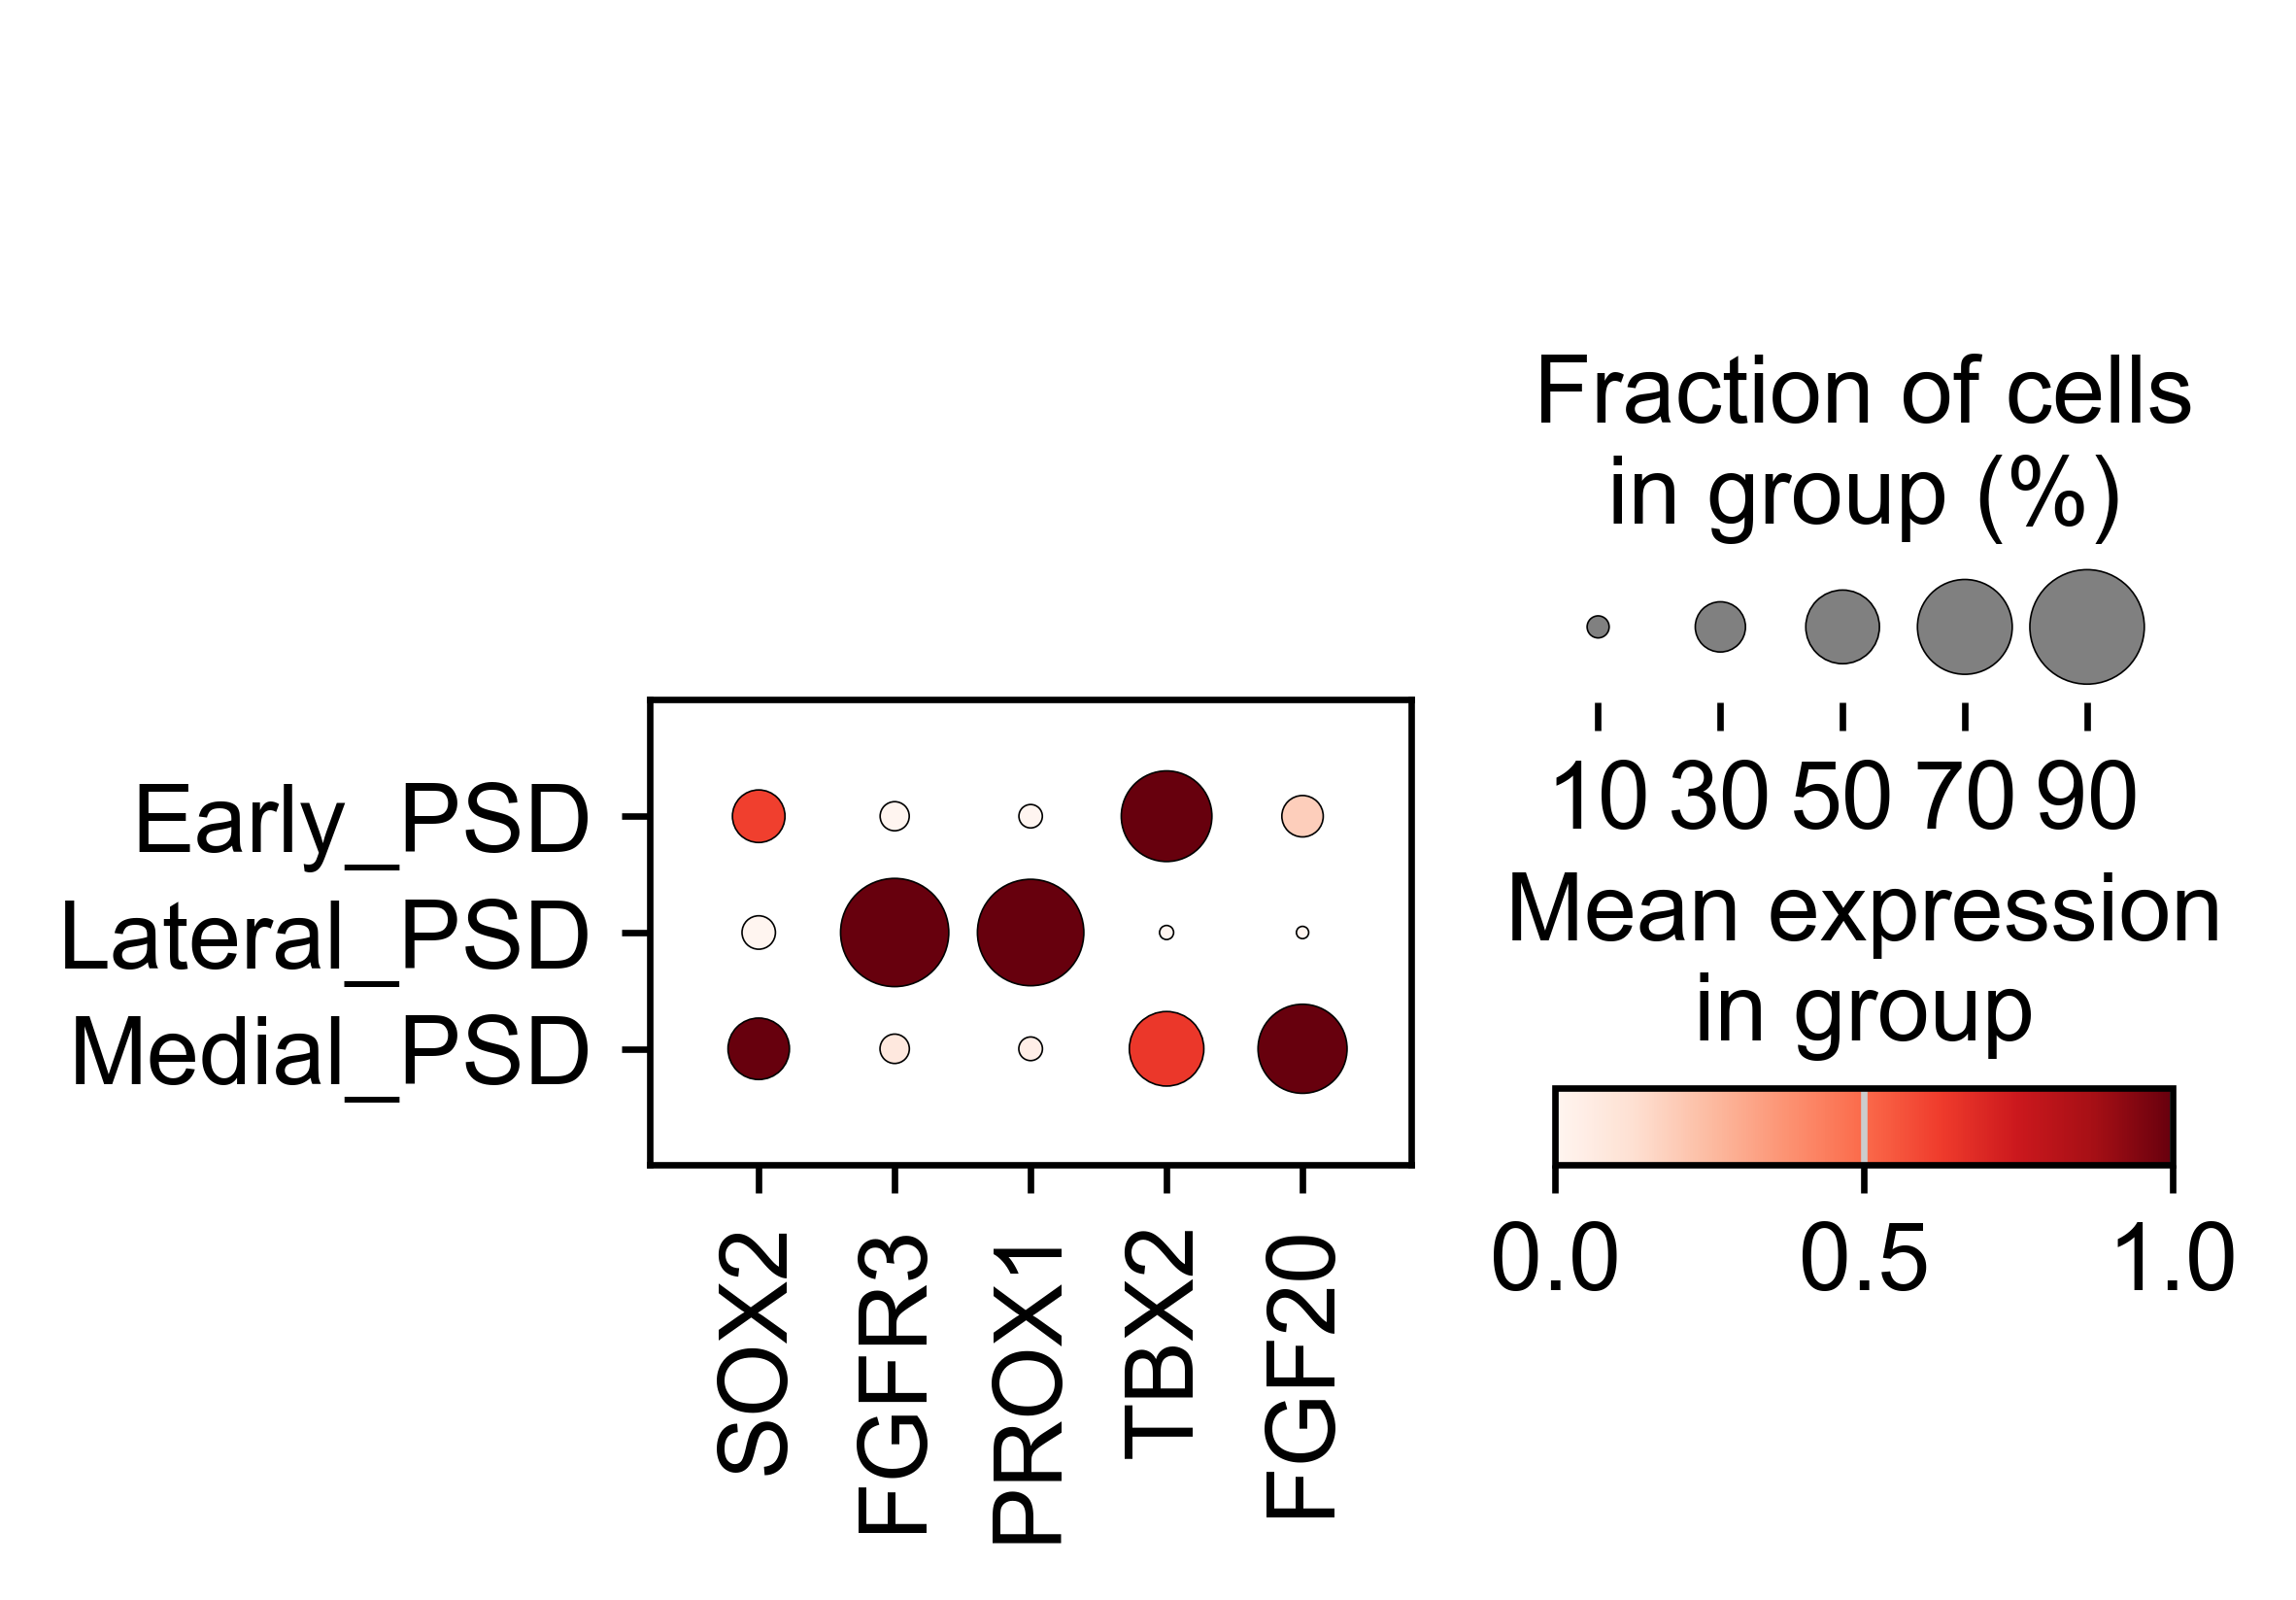

In [76]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=300,dpi_save=600)
#sc.tl.dendrogram(adata, groupby='cell_type_final')
sc.pl.dotplot(
    adata_new_PSD,
    groupby="cell_type3",
    var_names=["SOX2","FGFR3","PROX1","TBX2","FGF20",],
  #dendrogram=True,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
     save="human_fetal_cochlea_epithlium_refined_V2.pdf"
)

In [74]:
adata_new_PSD.obs['cell_type_sample'] = (adata_new_PSD.obs['cell_type3'].astype(str) + '_' + adata_new_PSD.obs['sample'].astype(str))

C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\3343330684.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_new_PSD.obs['cell_type_sample'] = (adata_new_PSD.obs['cell_type3'].astype(str) + '_' + adata_new_PSD.obs['sample'].astype(str))


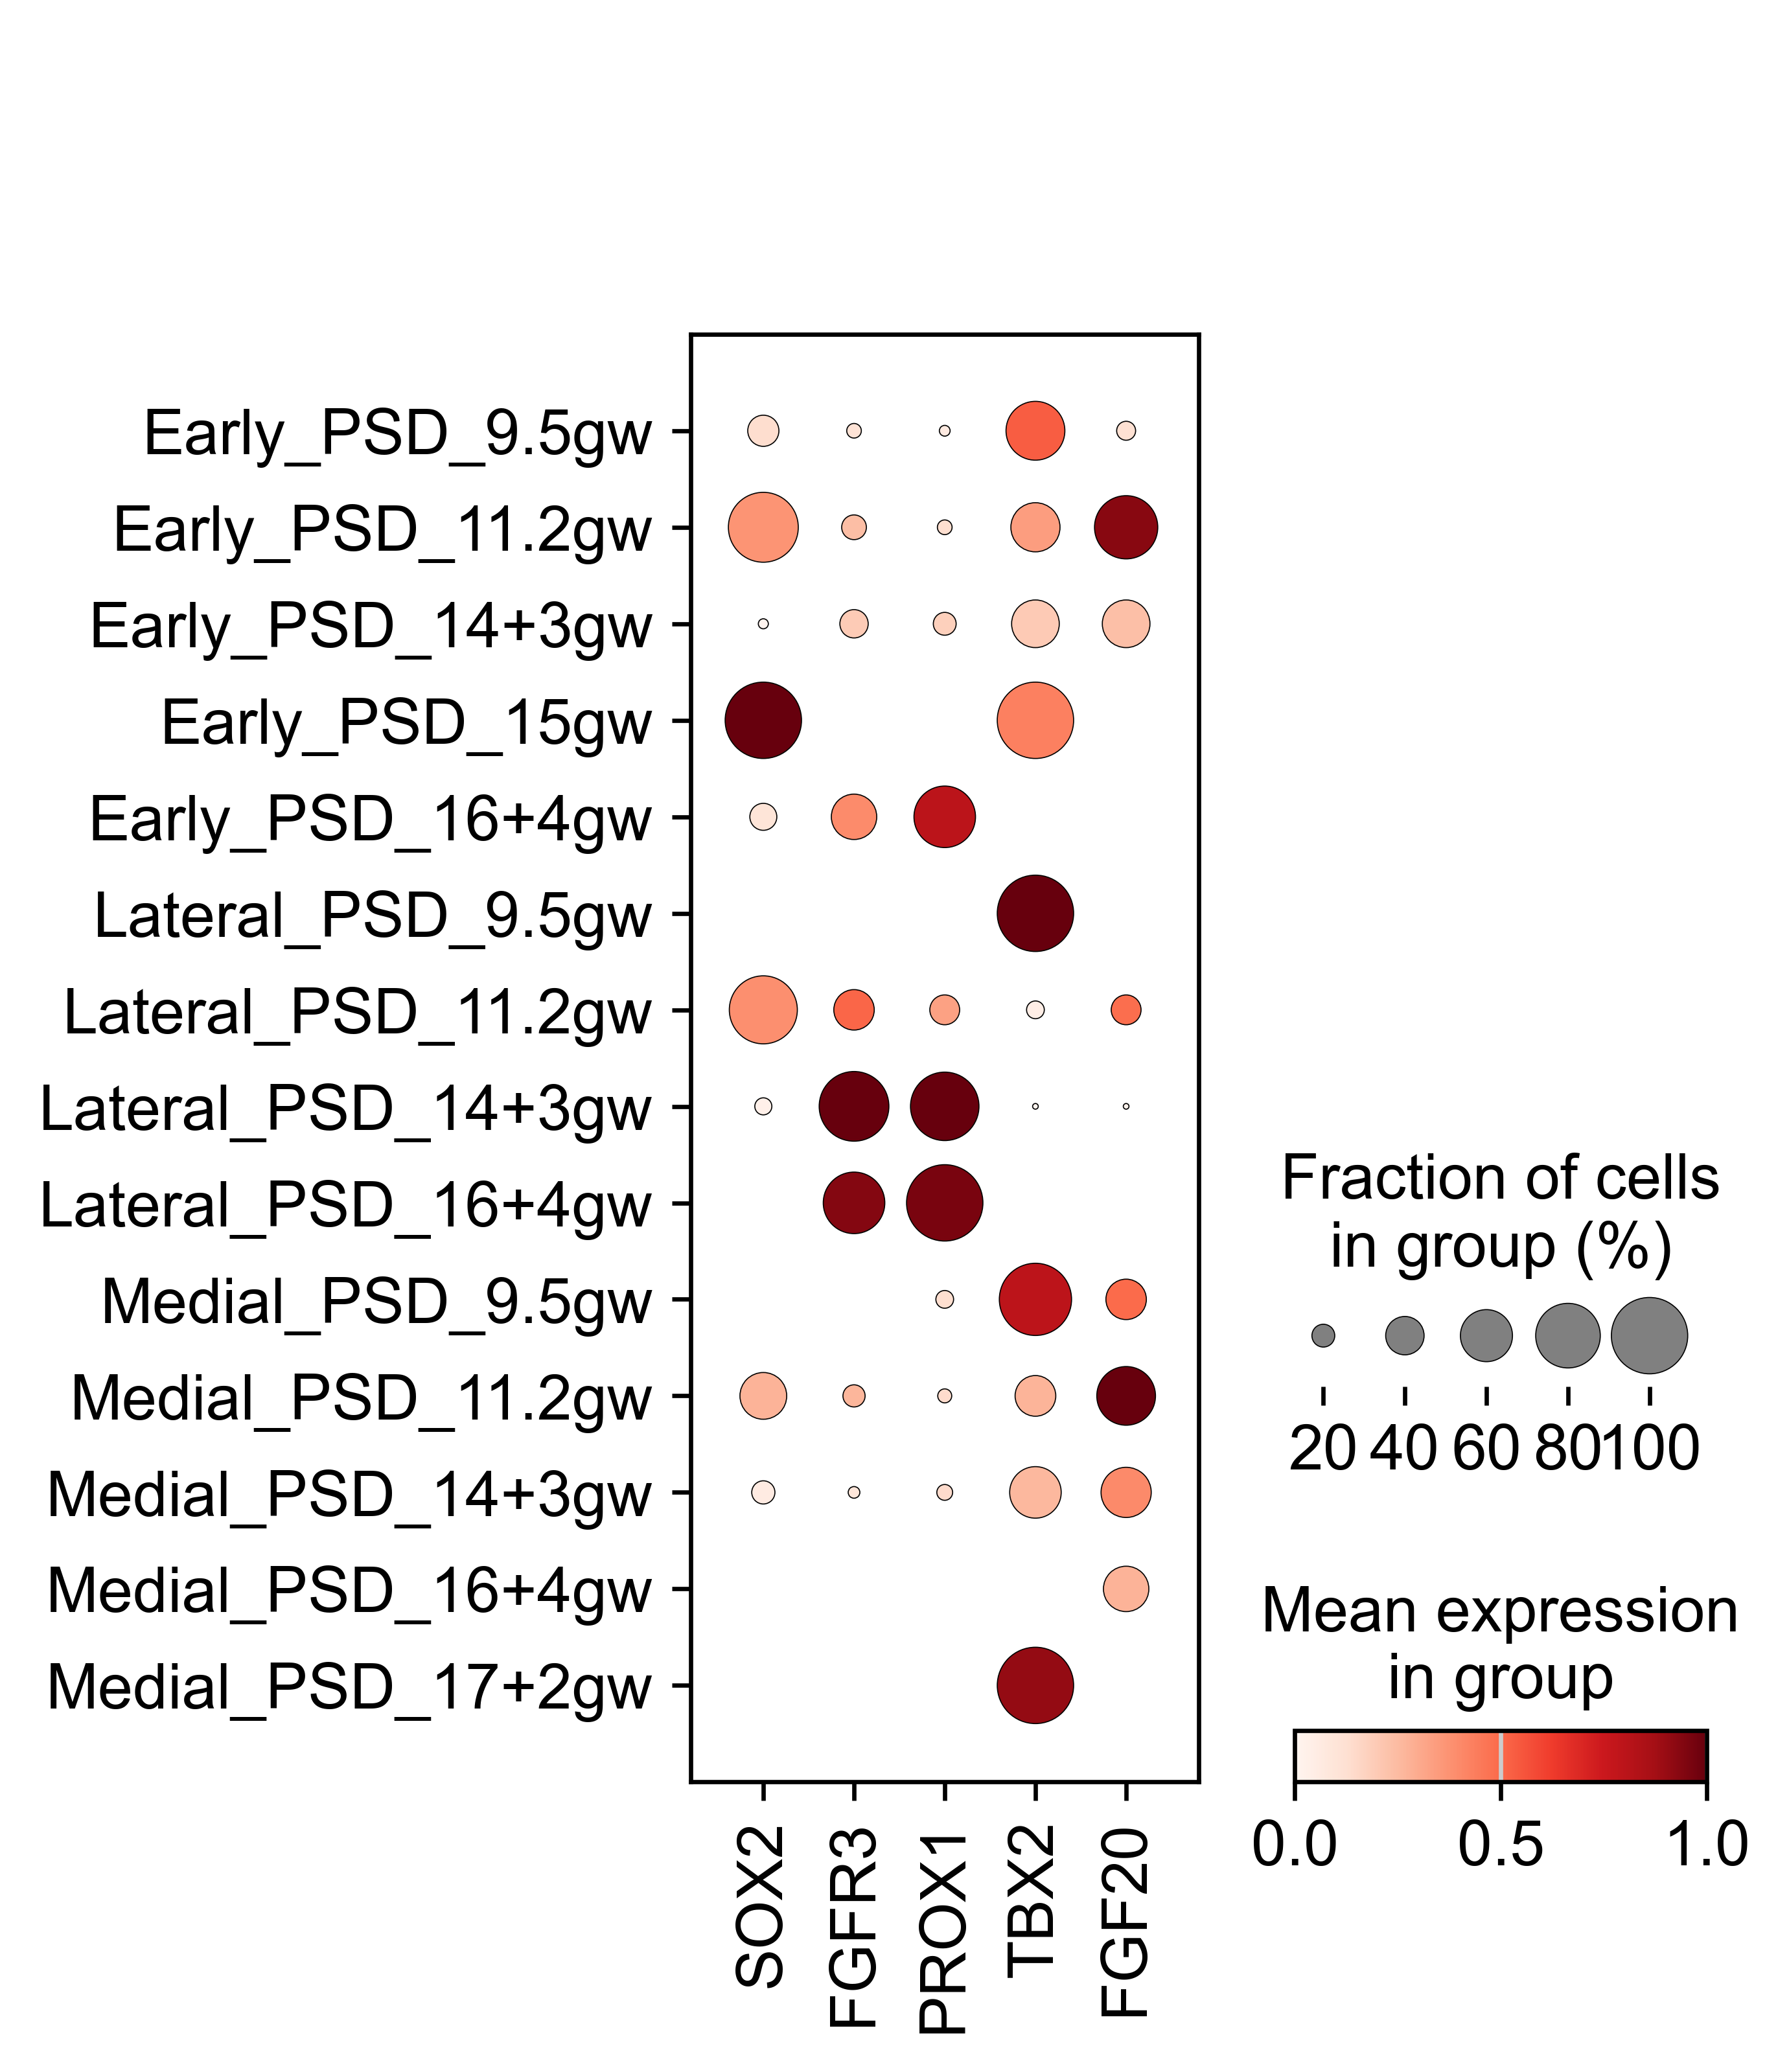

In [75]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=300,dpi_save=600)
#sc.tl.dendrogram(adata, groupby='cell_type_final')
sc.pl.dotplot(
    adata_new_PSD,
    groupby="cell_type_sample",
    var_names=["SOX2","FGFR3","PROX1","TBX2","FGF20",],
  #dendrogram=True,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
     save="human_fetal_cochlea_epithlium_refined_v3.pdf"
)

In [77]:
adata_new_PSD.obs['cell_type_sample'].value_counts()

cell_type_sample
Medial_PSD_11.2gw     125
Early_PSD_9.5gw       109
Lateral_PSD_14+3gw     96
Medial_PSD_14+3gw      49
Early_PSD_14+3gw       15
Medial_PSD_9.5gw       14
Early_PSD_11.2gw        9
Lateral_PSD_11.2gw      7
Early_PSD_16+4gw        4
Lateral_PSD_16+4gw      4
Lateral_PSD_9.5gw       2
Medial_PSD_16+4gw       2
Early_PSD_15gw          1
Medial_PSD_17+2gw       1
Name: count, dtype: int64

In [78]:
adata_new_PSD

AnnData object with n_obs × n_vars = 438 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'sample_id2', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'cell_type_final', 'cell_type_final_v2', 'cell_type_final_v3', 'cell_type_final_v4', 'low_ncounts', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'is_doublet_scrub', '_scvi_batch', '_scvi_labels', 'cell_type_final_v5', 'cell_type2', 'cell_type3', 'cell_type_sample', 'cell_type_final_v6'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gen

In [90]:
import pandas as pd
import anndata as ad

# 方法1：直接过滤adata对象
# 计算每个cell_type_sample的细胞数
cell_counts = adata_new_PSD.obs['cell_type_sample'].value_counts()
keep_categories = cell_counts[cell_counts >= 5].index.tolist()

# 过滤adata，保留细胞数>=40的样本
adata_filtered = adata_new_PSD[adata_new_PSD.obs['cell_type_sample'].isin(keep_categories)].copy()

# 查看过滤后的结果
print("过滤后的cell_type_sample分布：")
print(adata_filtered.obs['cell_type_sample'].value_counts())
print(f"\n过滤前细胞数: {adata_new_PSD.n_obs}")
print(f"过滤后细胞数: {adata_filtered.n_obs}")
print(f"移除的细胞数: {adata_new_PSD.n_obs - adata_filtered.n_obs}")


过滤后的cell_type_sample分布：
cell_type_sample
Medial_PSD_11.2gw     125
Early_PSD_9.5gw       109
Lateral_PSD_14+3gw     96
Medial_PSD_14+3gw      49
Early_PSD_14+3gw       15
Medial_PSD_9.5gw       14
Early_PSD_11.2gw        9
Lateral_PSD_11.2gw      7
Name: count, dtype: int64

过滤前细胞数: 438
过滤后细胞数: 424
移除的细胞数: 14


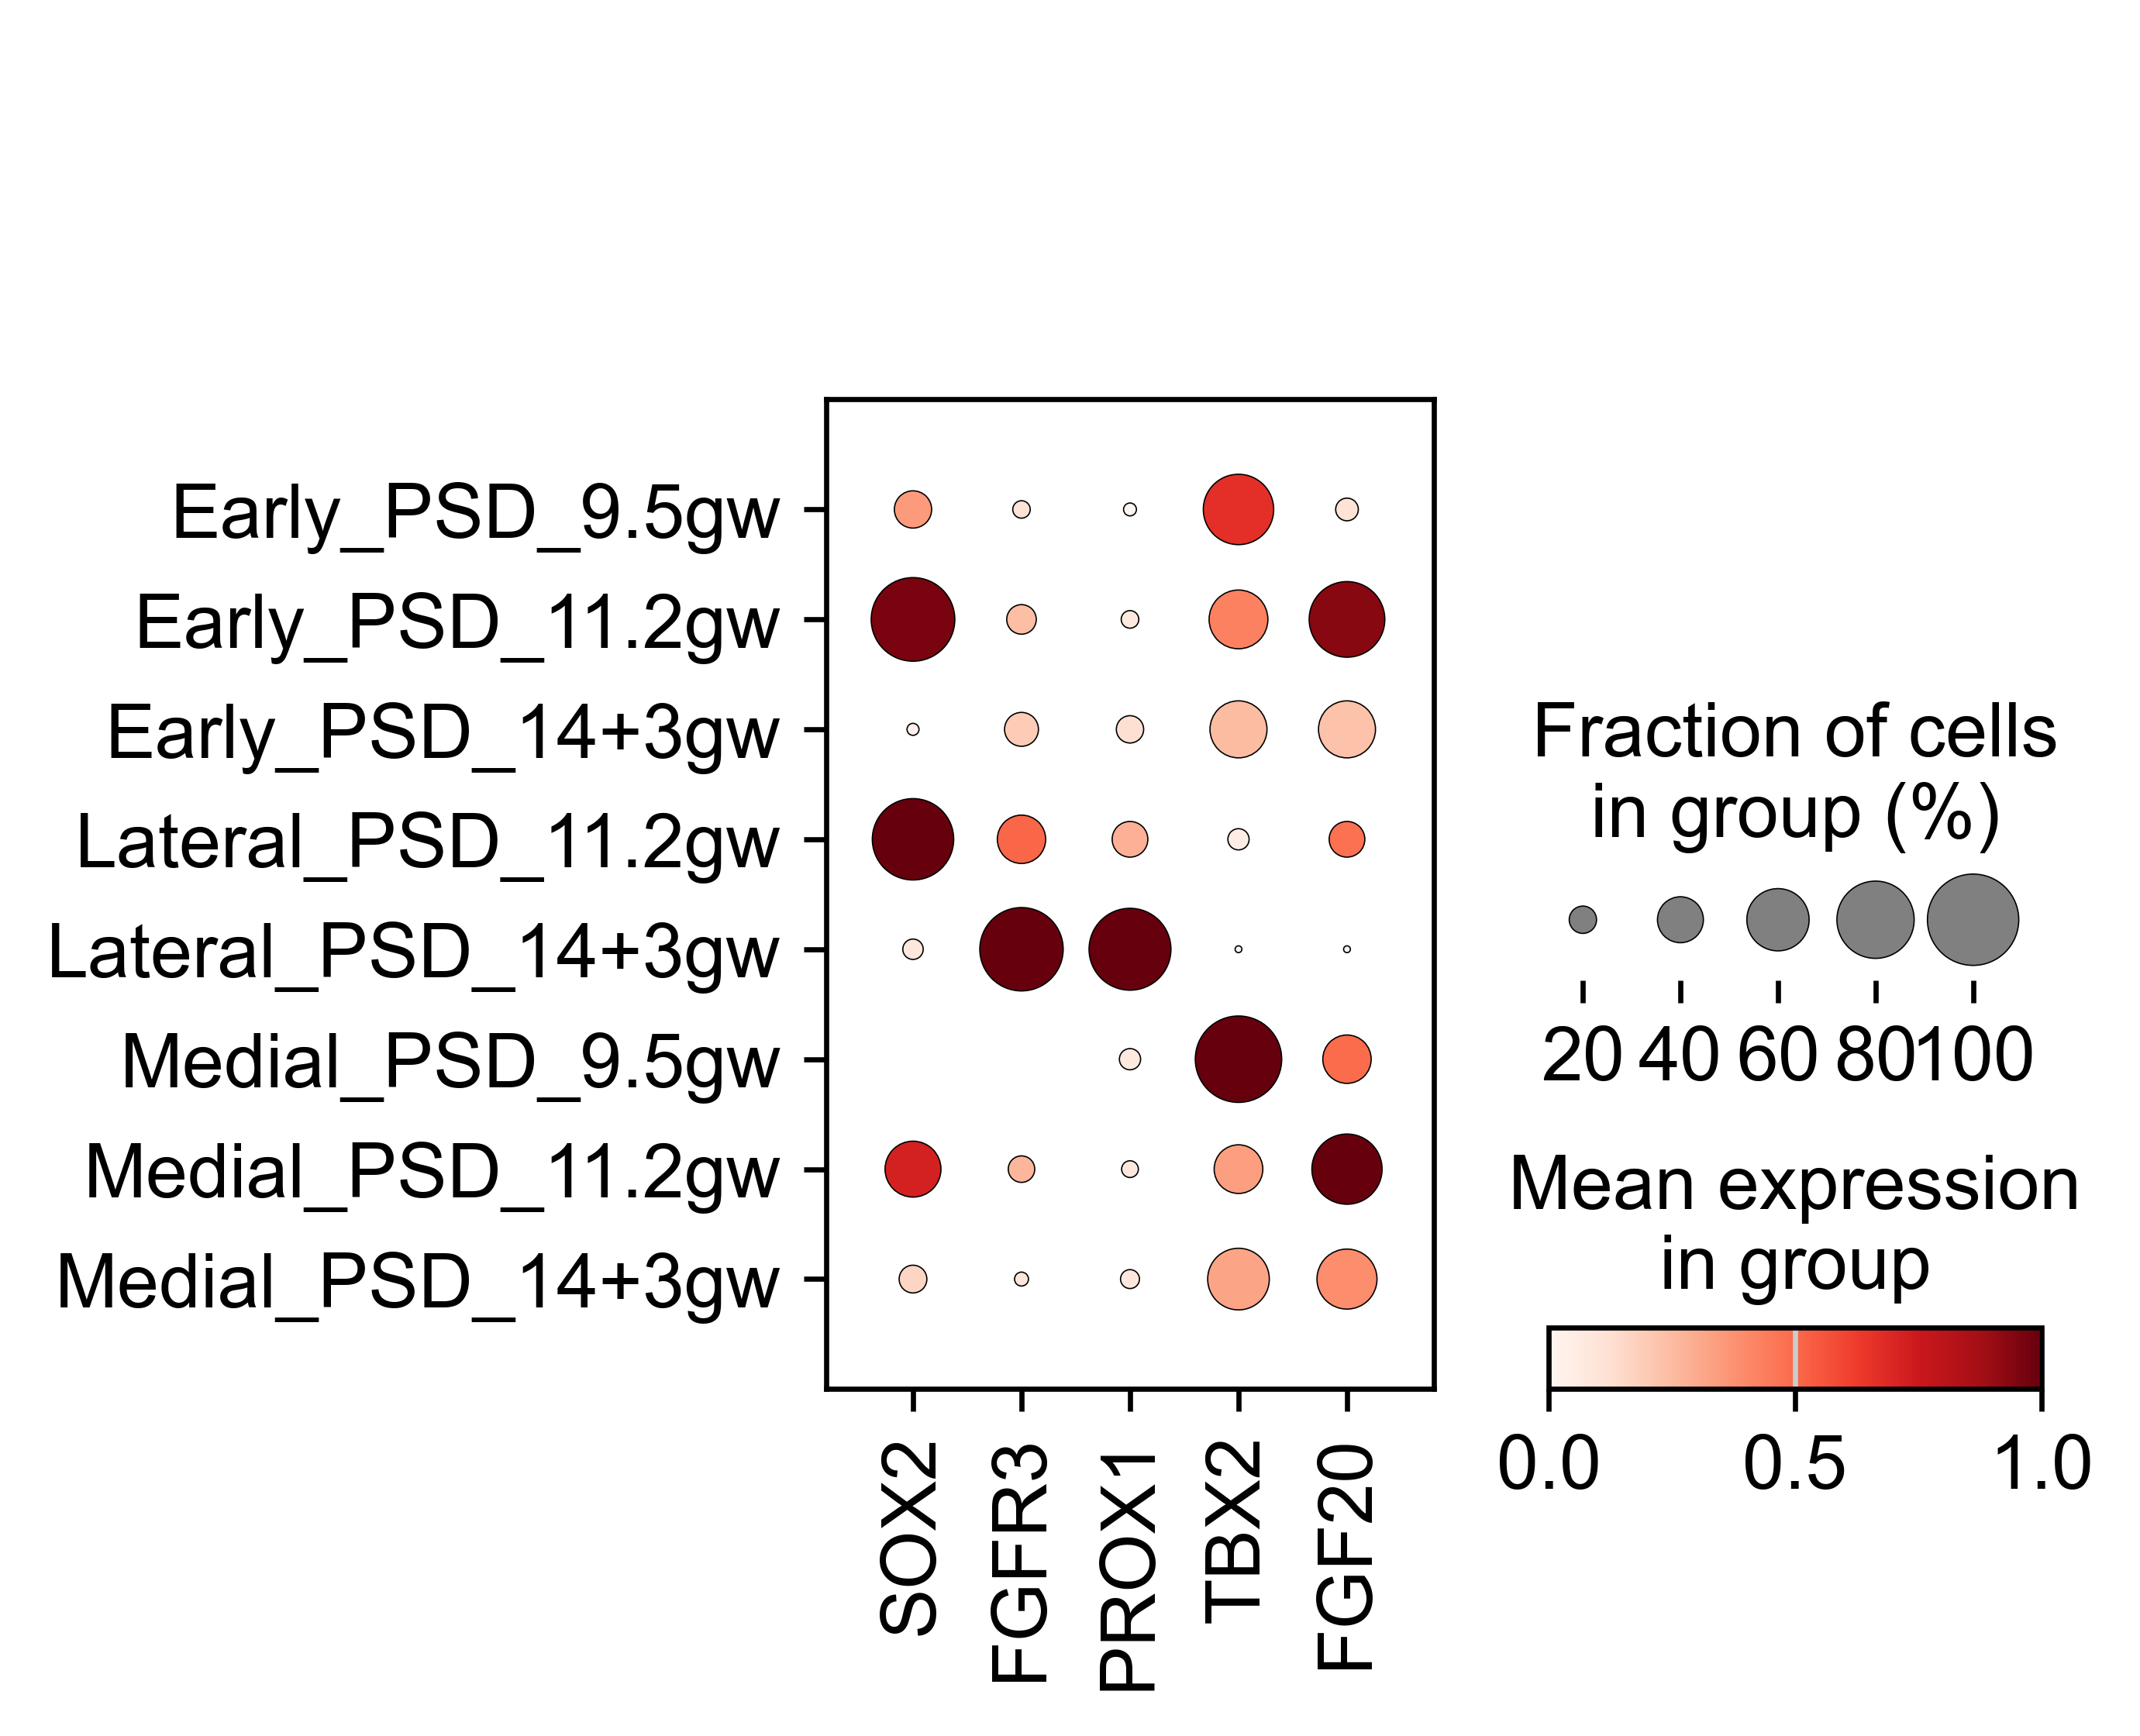

In [91]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=300,dpi_save=600)
#sc.tl.dendrogram(adata, groupby='cell_type_final')
sc.pl.dotplot(
    adata_filtered,
    groupby="cell_type_sample",
    var_names=["SOX2","FGFR3","PROX1","TBX2","FGF20",],
  #dendrogram=True,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
     save="human_fetal_cochlea_epithlium_refined_v3.pdf"
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\2742033111.py:48: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\2742033111.py:48: UserWarning: Glyph 28388 (\N{CJK UNIFIED IDEOGRAPH-6EE4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\2742033111.py:48: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\2742033111.py:48: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\2742033111.py:48: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_25068\2742033111.py:48: UserWarning: Glyph 32990 (\N{CJK UNIFIED IDEOGRAPH-80DE}) missi

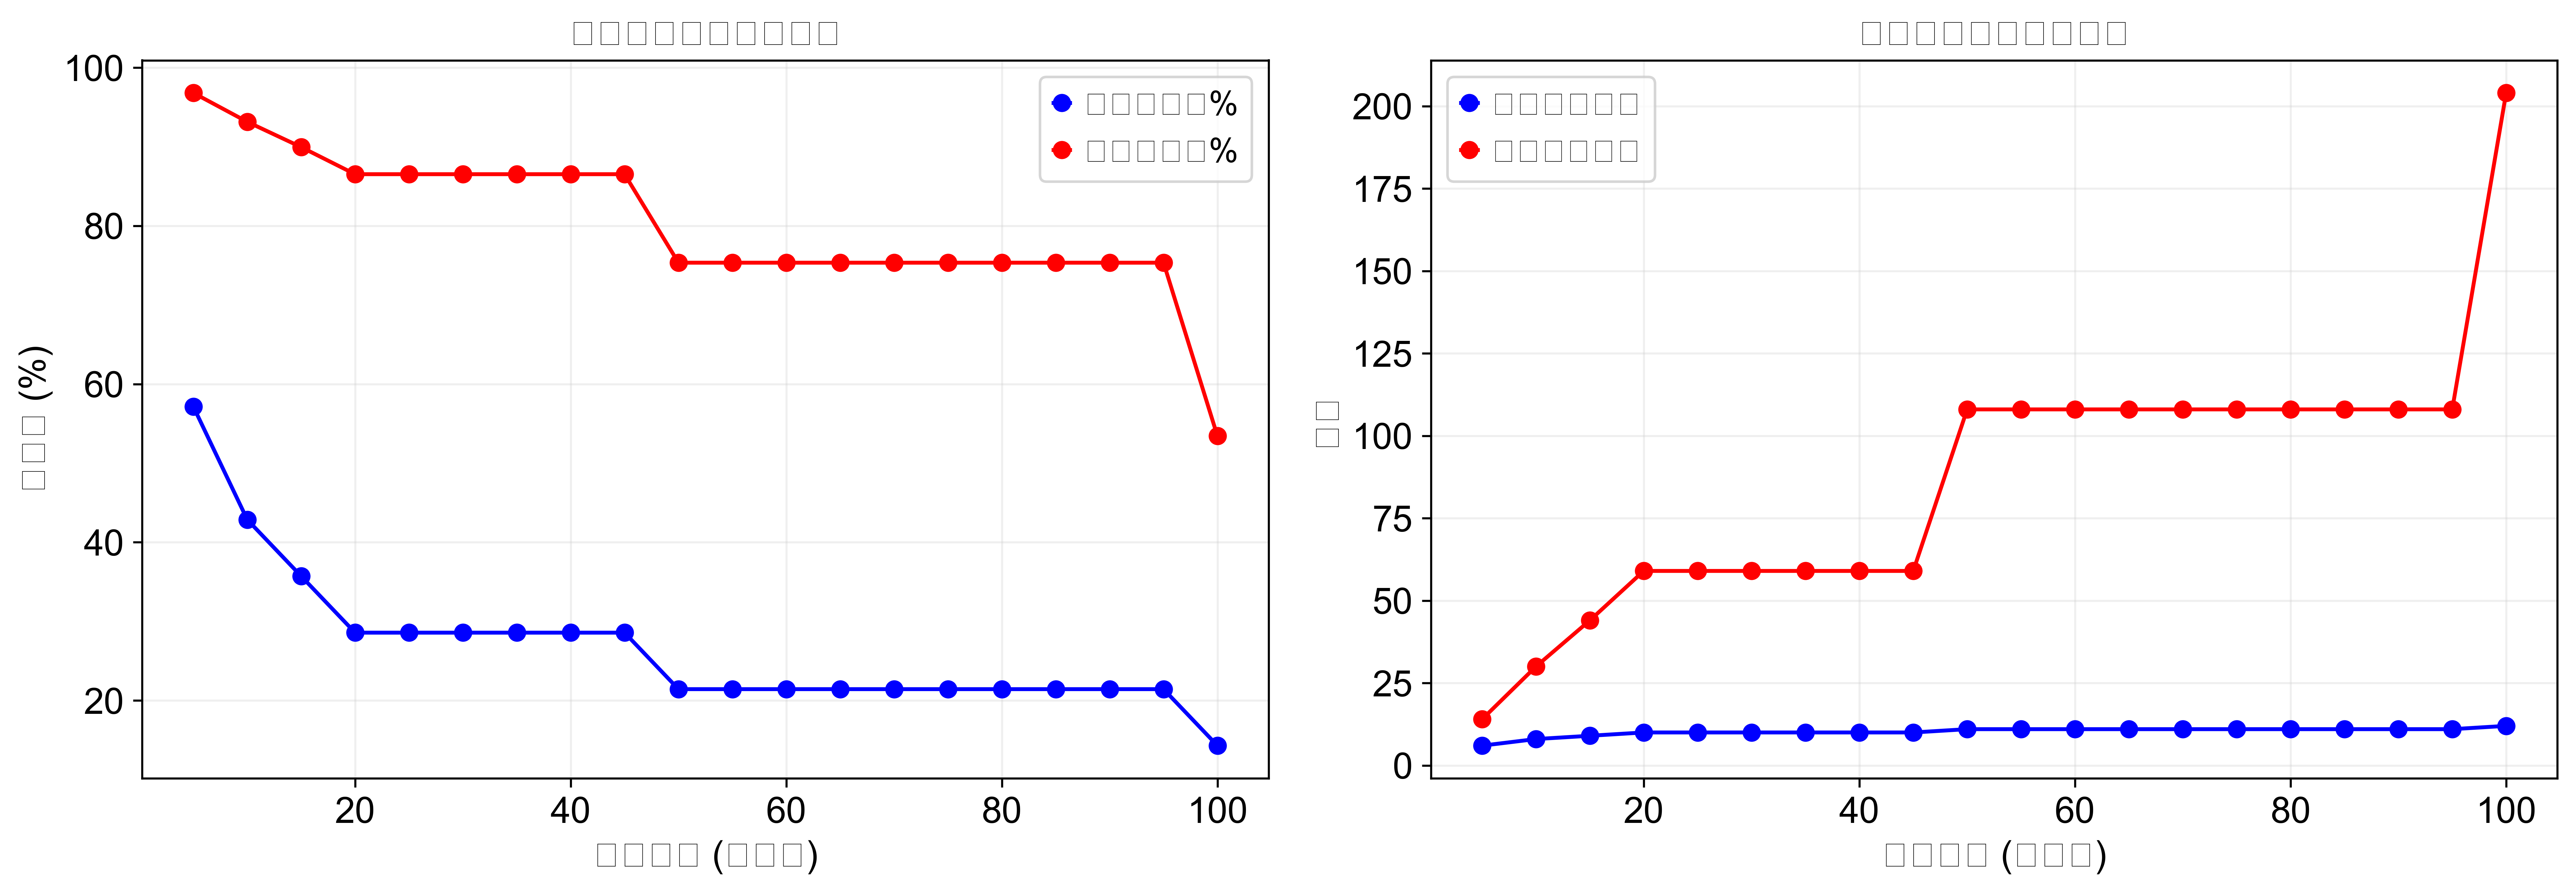


建议的最优阈值: 25


In [87]:
def simulate_threshold_impact(adata, cell_type_col='cell_type_sample', 
                             max_threshold=100, step=5):
    """
    模拟不同阈值对数据的影响
    """
    cell_counts = adata.obs[cell_type_col].value_counts()
    total_cells = adata.n_obs
    n_classes = len(cell_counts)
    
    thresholds = range(step, max_threshold + step, step)
    results = []
    
    for thresh in thresholds:
        keep_classes = cell_counts[cell_counts >= thresh].index
        cells_kept = np.sum(cell_counts[cell_counts >= thresh])
        
        results.append({
            'threshold': thresh,
            'classes_kept': len(keep_classes),
            'classes_removed': n_classes - len(keep_classes),
            'cells_kept': cells_kept,
            'cells_removed': total_cells - cells_kept,
            'pct_classes_kept': len(keep_classes) / n_classes * 100,
            'pct_cells_kept': cells_kept / total_cells * 100
        })
    
    results_df = pd.DataFrame(results)
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(results_df['threshold'], results_df['pct_classes_kept'], 'b-o', label='保留的类别%')
    axes[0].plot(results_df['threshold'], results_df['pct_cells_kept'], 'r-o', label='保留的细胞%')
    axes[0].set_xlabel('过滤阈值 (细胞数)')
    axes[0].set_ylabel('百分比 (%)')
    axes[0].set_title('阈值对数据保留的影响')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(results_df['threshold'], results_df['classes_removed'], 'b-o', label='移除的类别数')
    axes[1].plot(results_df['threshold'], results_df['cells_removed'], 'r-o', label='移除的细胞数')
    axes[1].set_xlabel('过滤阈值 (细胞数)')
    axes[1].set_ylabel('数量')
    axes[1].set_title('阈值对数据损失的影响')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results_df

# 应用方法4
results = simulate_threshold_impact(adata_new_PSD, step=5)

# 找到"肘部"点（边际收益递减点）
results['边际类别保留率'] = results['pct_classes_kept'].diff()
optimal_threshold = results.loc[results['边际类别保留率'].abs() < 1, 'threshold'].min()
print(f"\n建议的最优阈值: {optimal_threshold}")